## Fase 1: Carga de Datos, Exploración Inicial y Tratamiento de Valores Faltantes

### 1. Configuración y Carga

In [1]:
# Importación de librerías esenciales para manipulación de datos
import pandas as pd

# Importación de librerías para visualización narrativa
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de herramientas de scikit-learn permitidas para imputación
from sklearn.impute import SimpleImputer

# Configuración del estilo visual de seaborn para los gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Carga de datos cumpliendo el Guardrail G001: no alterar el archivo original
df_titanic = pd.read_csv('Titanic-Dataset.csv')

# Exploración inicial mostrando los primeros registros
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Análisis Exploratorio Inicial (EDA)

/tmp/ipykernel_41777/3000780611.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_titanic, x='Survived', palette=['#ff9999','#66b3ff'])
/tmp/ipykernel_41777/3000780611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


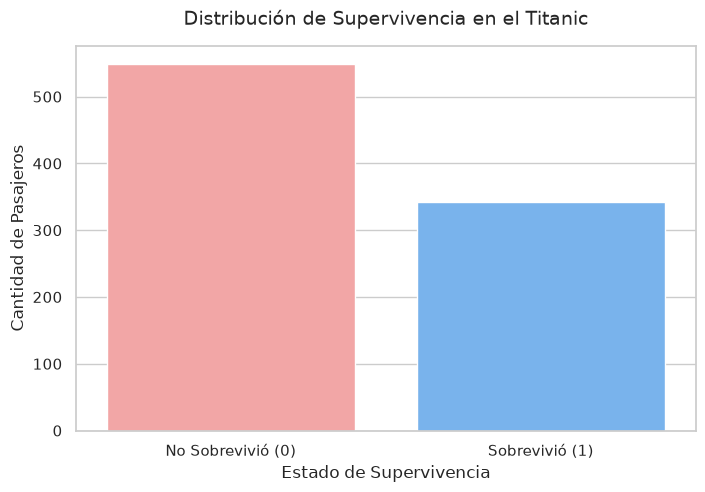

In [2]:
# Gráfico 1 de 15: Distribución de Supervivencia General
plt.figure(figsize=(8, 5))
# Contamos cuántos sobrevivieron y cuántos no
ax = sns.countplot(data=df_titanic, x='Survived', palette=['#ff9999','#66b3ff'])
# Renombramos los ejes para un mejor storytelling
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Distribución de Supervivencia en el Titanic', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

### Interpretación:

/tmp/ipykernel_41777/6067645.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


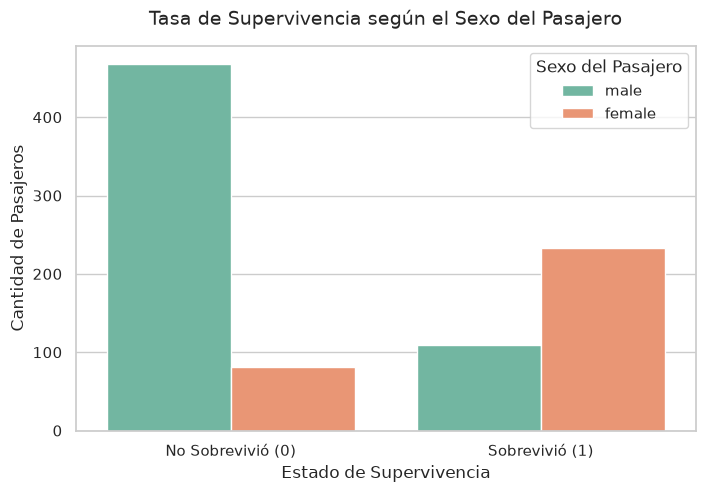

In [3]:
# Gráfico 2 de 15: Supervivencia Segmentada por Sexo
plt.figure(figsize=(8, 5))
# Evaluamos el impacto del género en la supervivencia
ax = sns.countplot(data=df_titanic, x='Survived', hue='Sex', palette='Set2')
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Tasa de Supervivencia según el Sexo del Pasajero', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Sexo del Pasajero')
plt.show()

### Interpretación:

/tmp/ipykernel_41777/1588591426.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


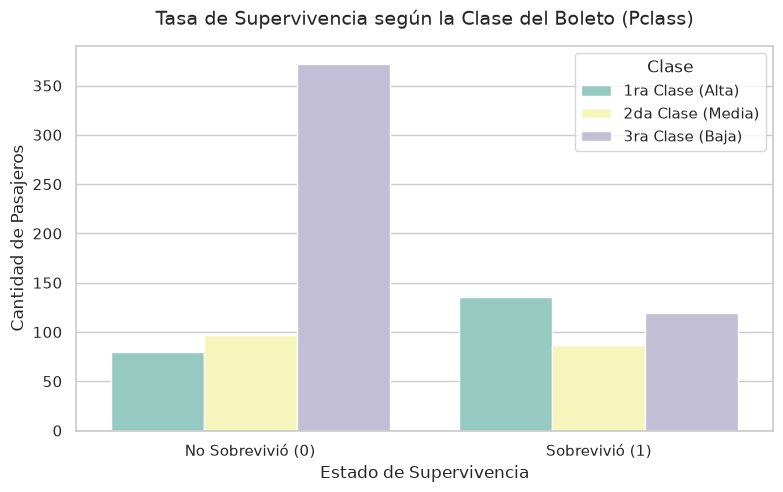

In [4]:
# Gráfico 3 de 15: Supervivencia Segmentada por Clase Económica
plt.figure(figsize=(9, 5))
# Mostramos cómo la clase del boleto influyó en el rescate
ax = sns.countplot(data=df_titanic, x='Survived', hue='Pclass', palette='Set3')
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Tasa de Supervivencia según la Clase del Boleto (Pclass)', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Clase', labels=['1ra Clase (Alta)', '2da Clase (Media)', '3ra Clase (Baja)'])
plt.show()

### Interpretación:

### 3. Diagnóstico y Tratamiento de Faltantes

Variables con valores nulos detectados:
 Age         177
Cabin       687
Embarked      2
dtype: int64


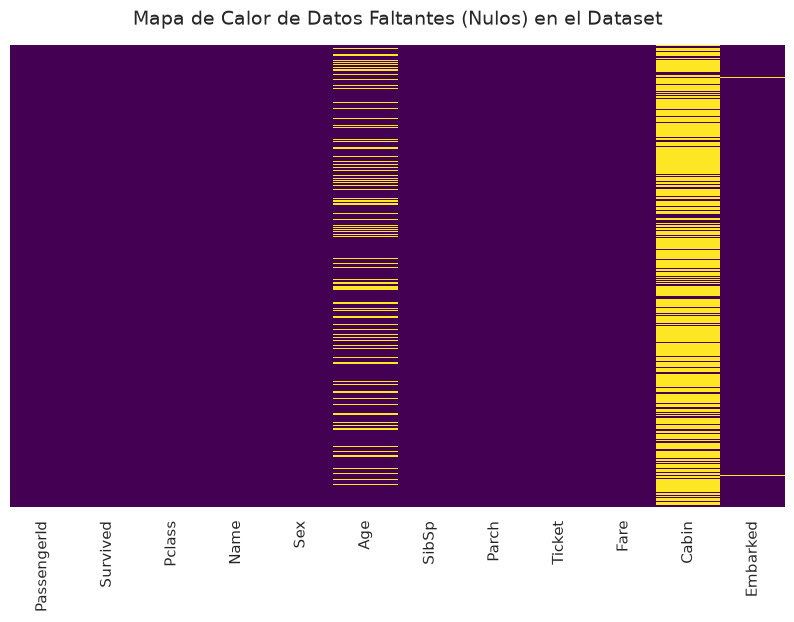

In [5]:
# Identificación inicial del volumen de datos nulos por atributo
nulos_por_columna = df_titanic.isnull().sum()
print("Variables con valores nulos detectados:\n", nulos_por_columna[nulos_por_columna > 0])

# Gráfico 4 de 15: Visualización de Vacíos (Heatmap de Nulos)
plt.figure(figsize=(10, 6))
# Mapeo visual donde las líneas amarillas representan datos faltantes
sns.heatmap(df_titanic.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes (Nulos) en el Dataset', fontsize=14, pad=15)
plt.show()

### Interpretación:

In [6]:
# Clonación del DataFrame original para realizar imputaciones sin perder el rastro de la fuente
df_clean = df_titanic.copy()

# Preservación de la columna Age original para una comparación estadística posterior
age_pre_imputacion = df_clean['Age'].copy()

### TRATAMIENTO DE FALTANTES ###

# 1. Tratamiento para 'Cabin'
# Justificación: Como vimos en el heatmap, la mayoría absoluta (>70%) de los datos de Cabin falta.
# Imputar tantos valores generaría un sesgo enorme e irreal. Por ello, es más seguro eliminar la columna entera.
df_clean.drop('Cabin', axis=1, inplace=True)

# 2. Tratamiento para 'Embarked'
# Justificación: Faltan solo 2 registros. Al ser categórica, la imputación por moda (el valor más común) 
# es estadísticamente segura y no altera la distribución.
imputador_moda = SimpleImputer(strategy='most_frequent')
df_clean['Embarked'] = imputador_moda.fit_transform(df_clean[['Embarked']]).ravel()

# 3. Tratamiento para 'Age'
# Justificación: La edad es crucial, pero falta aproximadamente un 20%. Al ser una distribución con ligera
# asimetría (sesgo por infantes), usamos la mediana en lugar de la media para mitigar el efecto de valores extremos.
imputador_mediana = SimpleImputer(strategy='median')
df_clean['Age'] = imputador_mediana.fit_transform(df_clean[['Age']]).ravel()

# Comprobación de que no queden datos nulos
print("Total de nulos restantes tras la Fase 1:", df_clean.isnull().sum().sum())

Total de nulos restantes tras la Fase 1: 0


### Interpretación:

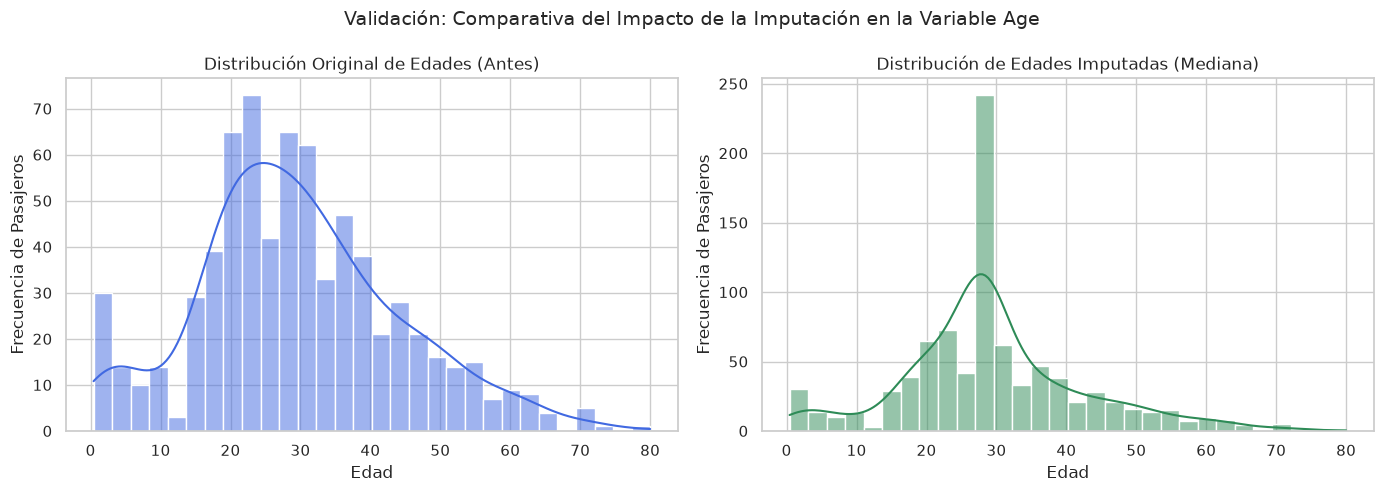

In [7]:
# Gráfico 5 de 15: Impacto de la imputación en la variable 'Age'
plt.figure(figsize=(14, 5))

# Gráfico de la distribución original (ignora nulos)
plt.subplot(1, 2, 1)
sns.histplot(age_pre_imputacion, kde=True, color='royalblue', bins=30)
plt.title('Distribución Original de Edades (Antes)', fontsize=12)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Pasajeros')

# Gráfico de la distribución luego de la imputación por Mediana
plt.subplot(1, 2, 2)
sns.histplot(df_clean['Age'], kde=True, color='seagreen', bins=30)
plt.title('Distribución de Edades Imputadas (Mediana)', fontsize=12)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Pasajeros')

plt.suptitle('Validación: Comparativa del Impacto de la Imputación en la Variable Age', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretación:

### Fase 2: Codificación de Variables Categóricas y Escalamiento de Variables Numéricas

#### 2.1 Codificación de Variables Categóricas


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Transformación de la variable 'Sex'
# Utilizamos un mapeo manual a 0 y 1 por ser una variable binaria simple y directa
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# 2. Transformación de la variable 'Embarked'
# JUSTIFICACIÓN: Se utiliza pd.get_dummies() (One-Hot Encoding) en lugar de LabelEncoder 
# debido a que los puertos de embarque (C, Q, S) representan variables nominales; 
# es decir, son categorías independientes que no tienen ningún orden jerárquico ni de magnitud.
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], prefix='Embarked', dtype=int)

df_clean.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1


### Interpretación:


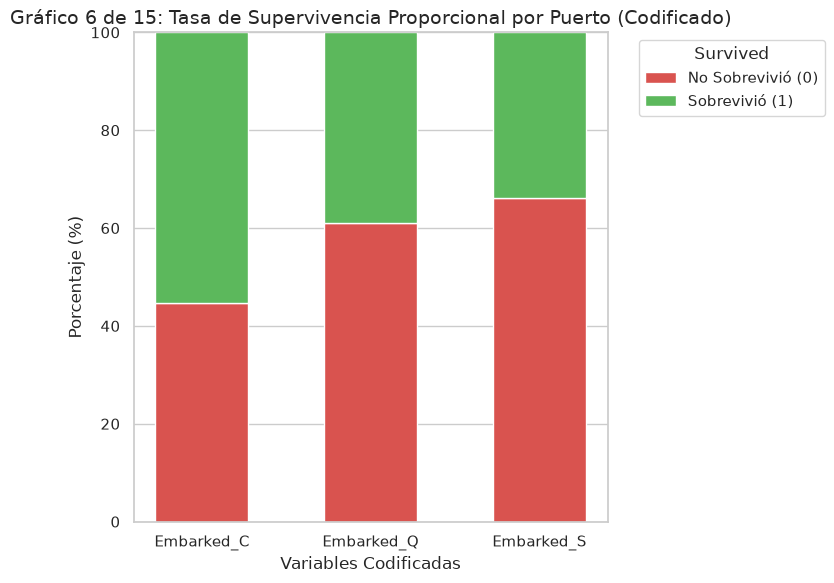

In [9]:
# Gráfico 6 de 15: Tasa de supervivencia según puerto de embarque codificado
fig, ax = plt.subplots(figsize=(8, 6))

# Filtramos las nuevas columnas codificadas de Embarked
embarked_cols = [col for col in df_clean.columns if col.startswith('Embarked_')]

survived_0_pct = []
survived_1_pct = []

# Calculamos proporciones para cada puerto codificado
for col in embarked_cols:
    subset = df_clean[df_clean[col] == 1]
    total = len(subset)
    if total > 0:
        survived_0_pct.append((len(subset[subset['Survived'] == 0]) / total) * 100)
        survived_1_pct.append((len(subset[subset['Survived'] == 1]) / total) * 100)
    else:
        survived_0_pct.append(0)
        survived_1_pct.append(0)

x = range(len(embarked_cols))
bar_width = 0.55

# Barras apiladas
ax.bar(x, survived_0_pct, width=bar_width, label='No Sobrevivió (0)', color='#d9534f')
ax.bar(x, survived_1_pct, width=bar_width, bottom=survived_0_pct, label='Sobrevivió (1)', color='#5cb85c')

# Corrección de Warning: set_xticks antes de set_xticklabels
ax.set_xticks(x)
ax.set_xticklabels(embarked_cols)

ax.set_title('Gráfico 6 de 15: Tasa de Supervivencia Proporcional por Puerto (Codificado)', fontsize=14)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_xlabel('Variables Codificadas', fontsize=12)
ax.legend(title='Survived', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


### Interpretación:


#### 2.2 Escalamiento de Variables Numéricas


In [10]:
# Seleccionamos las variables numéricas continuas
num_cols = ['Age', 'Fare']

# Guardamos copias de las series originales temporalmente para graficar el "Antes y Después"
age_original = df_clean['Age'].copy()
fare_original = df_clean['Fare'].copy()

# JUSTIFICACIÓN: Elegimos MinMaxScaler para escalar Age y Fare al rango fijo [0, 1].
# Se hace esta elección porque el escalamiento Min-Max preserva exactamente la forma original 
# de la distribución de los datos y las distancias proporcionales entre los valores, 
# evitando forzar una normalización estricta que deformaría variables sesgadas como 'Fare'.
scaler = MinMaxScaler()

df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Verificamos los cambios
df_clean[['Age', 'Fare']].head()


,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


### Interpretación:


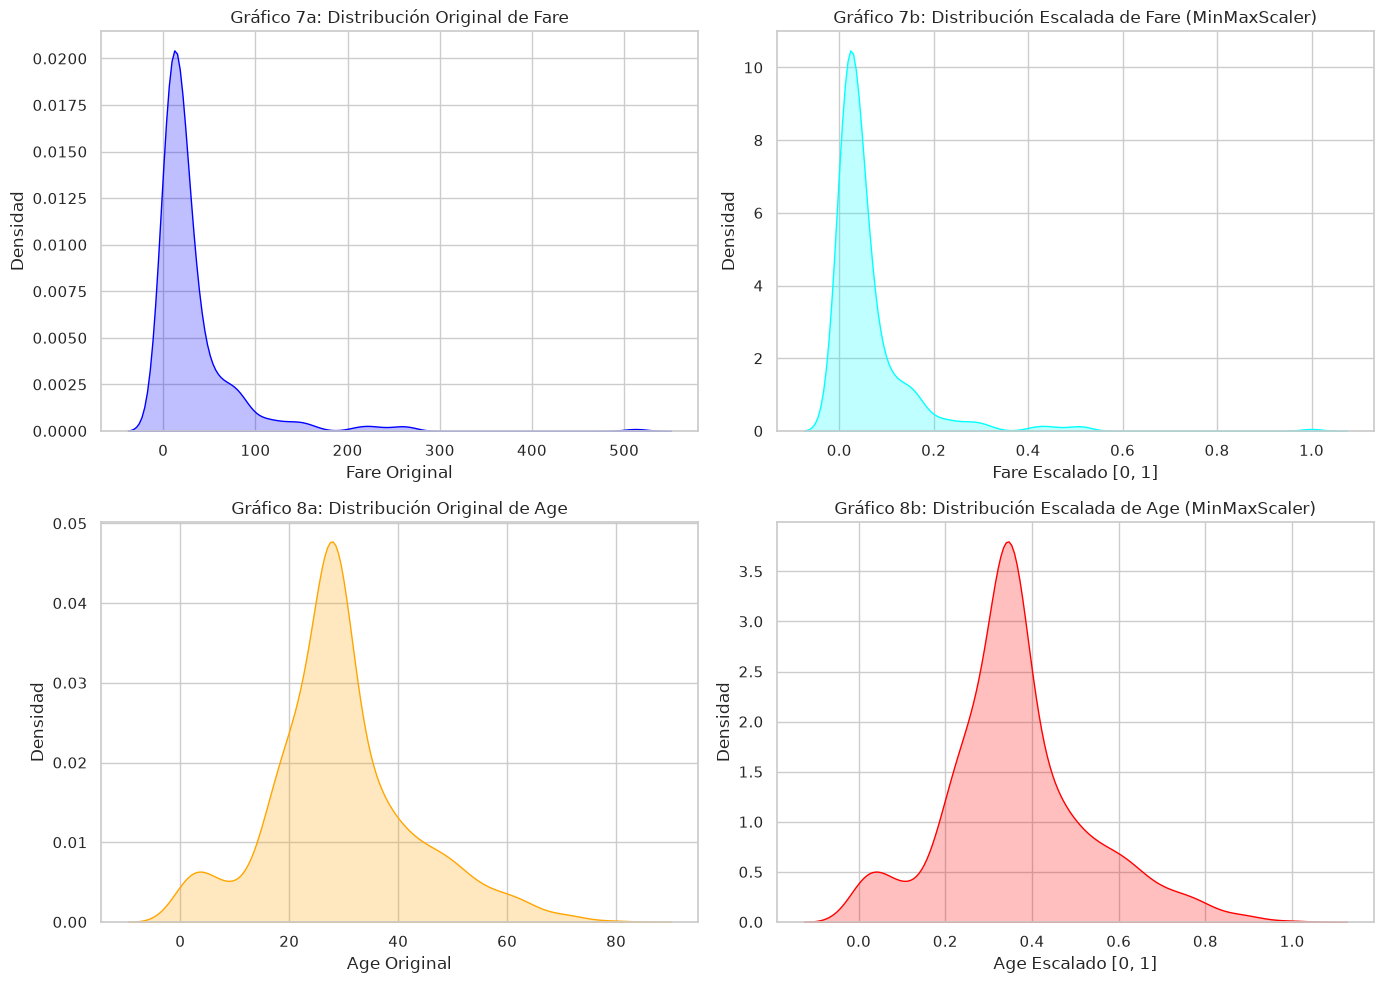

In [11]:
# Gráficos 7 y 8 de 15: Distribución "Antes y Después" del escalamiento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Gráfico 7: Distribución de Fare ---
sns.kdeplot(fare_original, ax=axes[0, 0], fill=True, color='blue')
axes[0, 0].set_title('Gráfico 7a: Distribución Original de Fare', fontsize=12)
axes[0, 0].set_xlabel('Fare Original')
axes[0, 0].set_ylabel('Densidad')

sns.kdeplot(df_clean['Fare'], ax=axes[0, 1], fill=True, color='cyan')
axes[0, 1].set_title('Gráfico 7b: Distribución Escalada de Fare (MinMaxScaler)', fontsize=12)
axes[0, 1].set_xlabel('Fare Escalado [0, 1]')
axes[0, 1].set_ylabel('Densidad')

# --- Gráfico 8: Distribución de Age ---
sns.kdeplot(age_original, ax=axes[1, 0], fill=True, color='orange')
axes[1, 0].set_title('Gráfico 8a: Distribución Original de Age', fontsize=12)
axes[1, 0].set_xlabel('Age Original')
axes[1, 0].set_ylabel('Densidad')

sns.kdeplot(df_clean['Age'], ax=axes[1, 1], fill=True, color='red')
axes[1, 1].set_title('Gráfico 8b: Distribución Escalada de Age (MinMaxScaler)', fontsize=12)
axes[1, 1].set_xlabel('Age Escalado [0, 1]')
axes[1, 1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()


### Interpretación:


## Fase 3: Ingeniería de Características (Feature Engineering) y Visualizaciones Finales

### 3.1 Creación de Nuevas Variables (Feature Engineering)

In [12]:
# =============================================================================
# INGENIERÍA DE CARACTERÍSTICAS — Fase 3
# =============================================================================
# JUSTIFICACIÓN TÉCNICA GENERAL:
# Las variables originales del dataset capturan información atómica (e.g. SibSp y Parch por separado).
# Sin embargo, muchos modelos de ML se benefician de variables derivadas que condensan
# patrones latentes y reducen la dimensionalidad semántica del problema.
# A continuación se crean 3 nuevas variables con fundamento estadístico y de dominio.

import numpy as np

# -----------------------------------------------------------------------
# Variable 1: Tamaño_Familia
# -----------------------------------------------------------------------
# SibSp = nro. de hermanos/esposos a bordo; Parch = nro. de padres/hijos a bordo.
# Sumamos ambos más 1 (el pasajero mismo) para obtener el tamaño del grupo familiar.
# JUSTIFICACIÓN ML: Esta variable captura el efecto del "grupo social" en la supervivencia.
# Familias muy grandes pudieron tener dificultades para evacuar juntas,
# mientras que los solitarios pudieron carecer de apoyo mutuo durante el desastre.
# Consolidar SibSp y Parch en una sola feature reduce colinealidad y mejora la
# capacidad predictiva al representar un concepto más abstracto con una sola dimensión.
df_clean['Tamaño_Familia'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# -----------------------------------------------------------------------
# Variable 2: Es_Solitario
# -----------------------------------------------------------------------
# Variable binaria: 1 si el pasajero viajaba completamente solo, 0 en caso contrario.
# JUSTIFICACIÓN ML: Las variables binarias derivadas actúan como "interruptores" que permiten
# a los modelos (especialmente los basados en árboles) crear splits más limpios.
# Se ha documentado ampliamente que los viajeros solitarios tuvieron tasas de supervivencia
# distintas a quienes viajaban en grupo, lo que convierte a esta feature en un predictor potente.
df_clean['Es_Solitario'] = (df_clean['Tamaño_Familia'] == 1).astype(int)

# -----------------------------------------------------------------------
# Variable 3: Titulo (extraído del nombre)
# -----------------------------------------------------------------------
# Extraemos el título social (Mr, Mrs, Miss, Master, etc.) de la columna 'Name'.
# JUSTIFICACIÓN ML: El título encapsula simultáneamente información de género, edad aproximada
# y estatus social/marital. Por ejemplo, 'Master' identifica niños varones, 'Mrs' a mujeres
# casadas, y títulos raros como 'Dr', 'Rev' indican profesiones de alto estatus.
# Agrupar títulos poco frecuentes en una categoría 'Otro' reduce el ruido y previene
# el overfitting que generaría tener demasiadas categorías dispersas.
df_clean['Titulo'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Agrupamos títulos poco frecuentes para evitar categorías con muy pocas observaciones
titulos_comunes = ['Mr', 'Mrs', 'Miss', 'Master']
df_clean['Titulo'] = df_clean['Titulo'].apply(
    lambda x: x if x in titulos_comunes else 'Otro'
)

# Codificamos el Titulo con LabelEncoder para que sea consumible por modelos numéricos
# JUSTIFICACIÓN: Aunque el título podría tratarse con OneHotEncoding, dado que ya lo agrupamos
# en 5 categorías manejables y algunos modelos (e.g. XGBoost, Random Forest) manejan bien
# variables ordinales codificadas, LabelEncoder es una opción eficiente aquí.
from sklearn.preprocessing import LabelEncoder
le_titulo = LabelEncoder()
df_clean['Titulo_Encoded'] = le_titulo.fit_transform(df_clean['Titulo'])

# Verificación de las nuevas columnas creadas
print("Nuevas variables creadas exitosamente:")
print(df_clean[['Name', 'Titulo', 'Titulo_Encoded', 'SibSp', 'Parch', 'Tamaño_Familia', 'Es_Solitario']].head(10))
print(f"\nDistribución de Títulos:\n{df_clean['Titulo'].value_counts()}")
print(f"\nDistribución de Tamaño_Familia:\n{df_clean['Tamaño_Familia'].value_counts().sort_index()}")
print(f"\nProporciones de Es_Solitario:\n{df_clean['Es_Solitario'].value_counts()}")

Nuevas variables creadas exitosamente:
                                                Name  Titulo  Titulo_Encoded  \
0                            Braund, Mr. Owen Harris      Mr               2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs               3   
2                             Heikkinen, Miss. Laina    Miss               1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs               3   
4                           Allen, Mr. William Henry      Mr               2   
5                                   Moran, Mr. James      Mr               2   
6                            McCarthy, Mr. Timothy J      Mr               2   
7                     Palsson, Master. Gosta Leonard  Master               0   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)     Mrs               3   
9                Nasser, Mrs. Nicholas (Adele Achem)     Mrs               3   

   SibSp  Parch  Tamaño_Familia  Es_Solitario  
0      1      0               2 

### Interpretación:

### 3.2 Visualizaciones de Storytelling — Gráficos 9 al 15

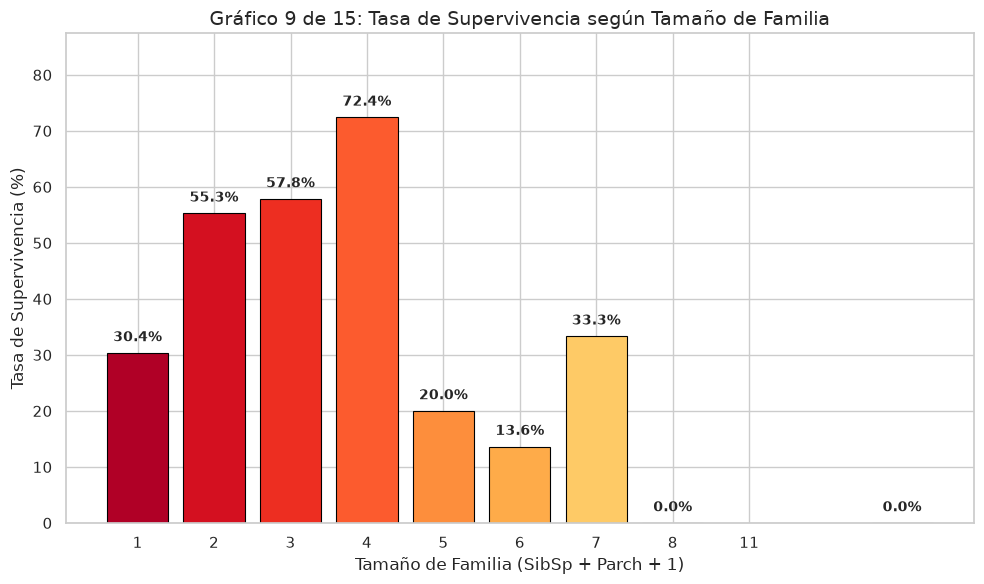

In [13]:
# Gráfico 9 de 15: Tasa de Supervivencia según Tamaño de Familia
# Este gráfico revela si viajar en familia mejoraba o empeoraba las probabilidades de sobrevivir.
fig, ax = plt.subplots(figsize=(10, 6))

# Calculamos la tasa de supervivencia promedio para cada tamaño de familia
supervivencia_familia = df_clean.groupby('Tamaño_Familia')['Survived'].mean() * 100

# Usamos un gráfico de barras con paleta degradada para resaltar diferencias
barras = ax.bar(
    supervivencia_familia.index,
    supervivencia_familia.values,
    color=sns.color_palette("YlOrRd_r", len(supervivencia_familia)),
    edgecolor='black',
    linewidth=0.8
)

# Añadimos etiquetas de porcentaje sobre cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2., altura + 1.5,
        f'{altura:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Corrección de Warning: set_xticks antes de set_xticklabels
ax.set_xticks(range(1, len(supervivencia_familia) + 1))
ax.set_xticklabels([str(i) for i in supervivencia_familia.index])

ax.set_title('Gráfico 9 de 15: Tasa de Supervivencia según Tamaño de Familia', fontsize=14)
ax.set_xlabel('Tamaño de Familia (SibSp + Parch + 1)', fontsize=12)
ax.set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
ax.set_ylim(0, max(supervivencia_familia.values) + 15)

plt.tight_layout()
plt.show()

### Interpretación:

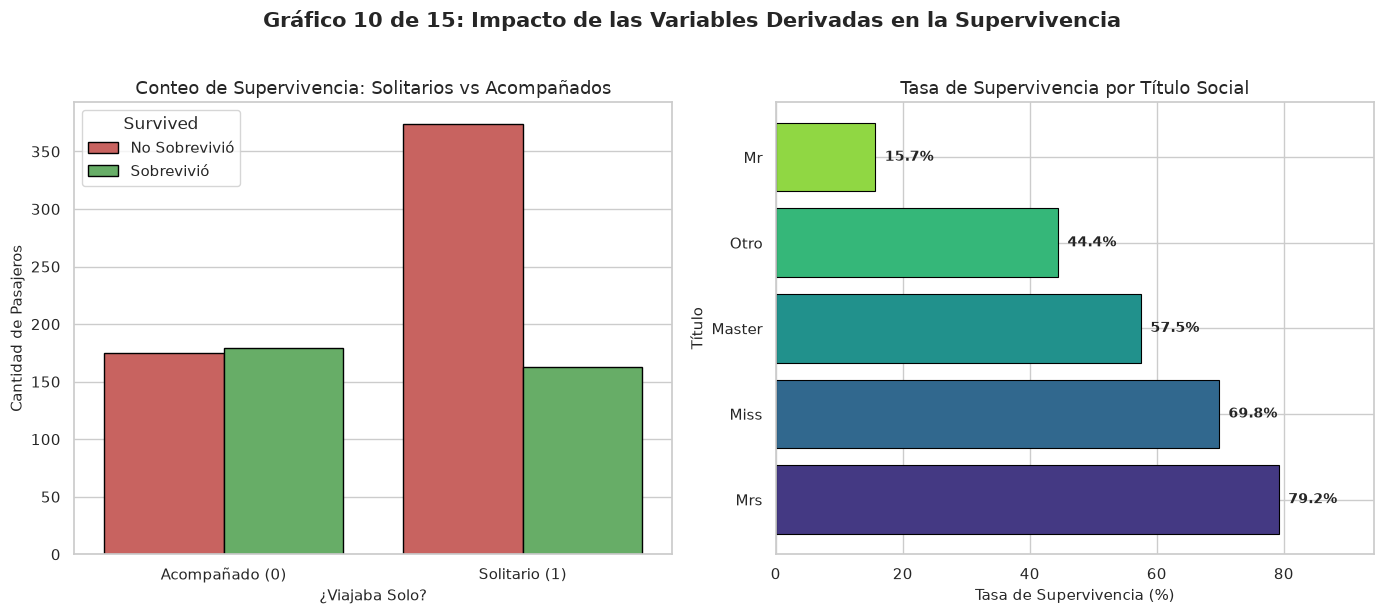

In [14]:
# Gráfico 10 de 15: Supervivencia de Pasajeros Solitarios vs. Acompañados
# Comparamos directamente si viajar solo era una desventaja en el desastre.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot izquierdo: Countplot de supervivencia por Es_Solitario ---
ax1 = axes[0]
sns.countplot(data=df_clean, x='Es_Solitario', hue='Survived', ax=ax1,
              palette={0: '#d9534f', 1: '#5cb85c'}, edgecolor='black')

# Corrección de Warning: set_xticks antes de set_xticklabels
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Acompañado (0)', 'Solitario (1)'])
ax1.set_title('Conteo de Supervivencia: Solitarios vs Acompañados', fontsize=13)
ax1.set_xlabel('¿Viajaba Solo?', fontsize=11)
ax1.set_ylabel('Cantidad de Pasajeros', fontsize=11)
ax1.legend(title='Survived', labels=['No Sobrevivió', 'Sobrevivió'])

# --- Subplot derecho: Supervivencia por Título Social ---
ax2 = axes[1]
supervivencia_titulo = df_clean.groupby('Titulo')['Survived'].mean() * 100
supervivencia_titulo = supervivencia_titulo.sort_values(ascending=False)

barras = ax2.barh(
    supervivencia_titulo.index,
    supervivencia_titulo.values,
    color=sns.color_palette("viridis", len(supervivencia_titulo)),
    edgecolor='black',
    linewidth=0.8
)

# Etiquetas de porcentaje al final de cada barra
for barra in barras:
    ancho = barra.get_width()
    ax2.text(ancho + 1.5, barra.get_y() + barra.get_height() / 2.,
             f'{ancho:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

ax2.set_title('Tasa de Supervivencia por Título Social', fontsize=13)
ax2.set_xlabel('Tasa de Supervivencia (%)', fontsize=11)
ax2.set_ylabel('Título', fontsize=11)
ax2.set_xlim(0, max(supervivencia_titulo.values) + 15)

plt.suptitle('Gráfico 10 de 15: Impacto de las Variables Derivadas en la Supervivencia',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretación:

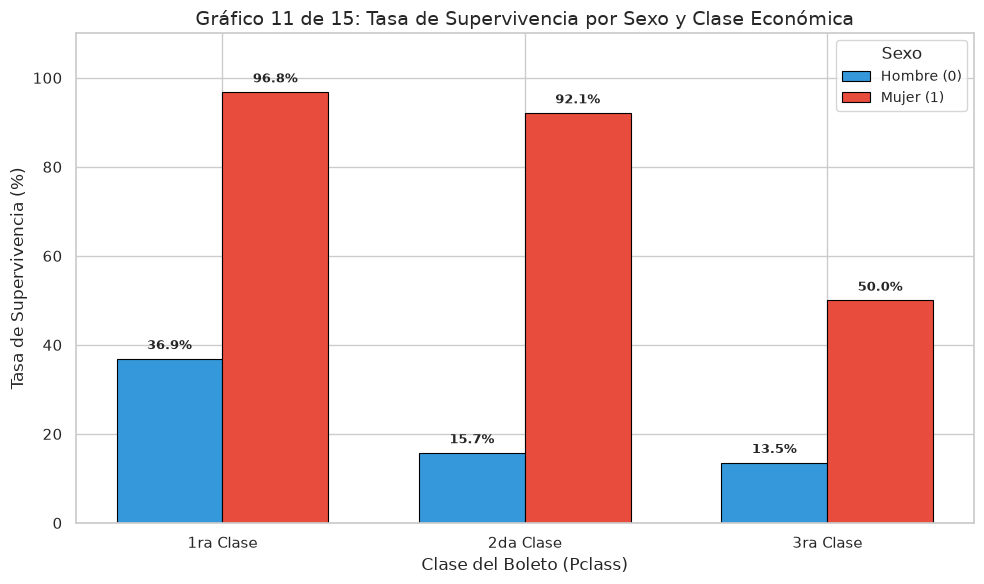

In [15]:
# Gráfico 11 de 15: Supervivencia por Sexo y Clase Económica (Análisis Multivariado)
# Exploramos la interacción de dos factores clave simultáneamente.
# La regla "Mujeres y niños primero" ¿se aplicó equitativamente entre clases?
fig, ax = plt.subplots(figsize=(10, 6))

# Creamos una tabla pivote con la tasa de supervivencia por Sexo y Pclass
pivot_data = df_clean.pivot_table(
    values='Survived', index='Pclass', columns='Sex', aggfunc='mean'
) * 100

# Gráfico de barras agrupadas
x = np.arange(len(pivot_data.index))
width = 0.35

barras_hombre = ax.bar(x - width/2, pivot_data[0], width, label='Hombre (0)',
                       color='#3498db', edgecolor='black', linewidth=0.8)
barras_mujer = ax.bar(x + width/2, pivot_data[1], width, label='Mujer (1)',
                      color='#e74c3c', edgecolor='black', linewidth=0.8)

# Etiquetas sobre las barras
for barra in barras_hombre:
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., h + 1.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for barra in barras_mujer:
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., h + 1.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Corrección de Warning: set_xticks antes de set_xticklabels
ax.set_xticks(x)
ax.set_xticklabels(['1ra Clase', '2da Clase', '3ra Clase'])

ax.set_title('Gráfico 11 de 15: Tasa de Supervivencia por Sexo y Clase Económica', fontsize=14)
ax.set_xlabel('Clase del Boleto (Pclass)', fontsize=12)
ax.set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.legend(title='Sexo', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretación:

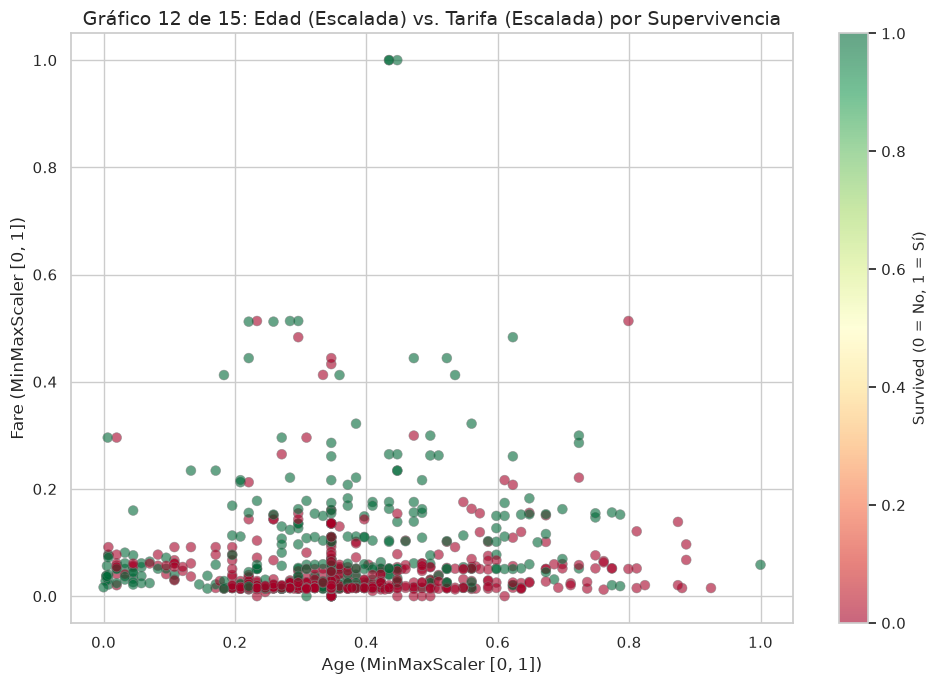

In [16]:
# Gráfico 12 de 15: Edad vs. Tarifa coloreado por Supervivencia (Scatterplot Bivariado)
# Este gráfico permite observar clusters y patrones ocultos en el espacio continuo Edad-Tarifa.
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot con transparencia para visualizar densidad
scatter = ax.scatter(
    df_clean['Age'],
    df_clean['Fare'],
    c=df_clean['Survived'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='gray',
    linewidth=0.5,
    s=50
)

# Barra de color indicando supervivencia
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Survived (0 = No, 1 = Sí)', fontsize=11)

ax.set_title('Gráfico 12 de 15: Edad (Escalada) vs. Tarifa (Escalada) por Supervivencia', fontsize=14)
ax.set_xlabel('Age (MinMaxScaler [0, 1])', fontsize=12)
ax.set_ylabel('Fare (MinMaxScaler [0, 1])', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretación:

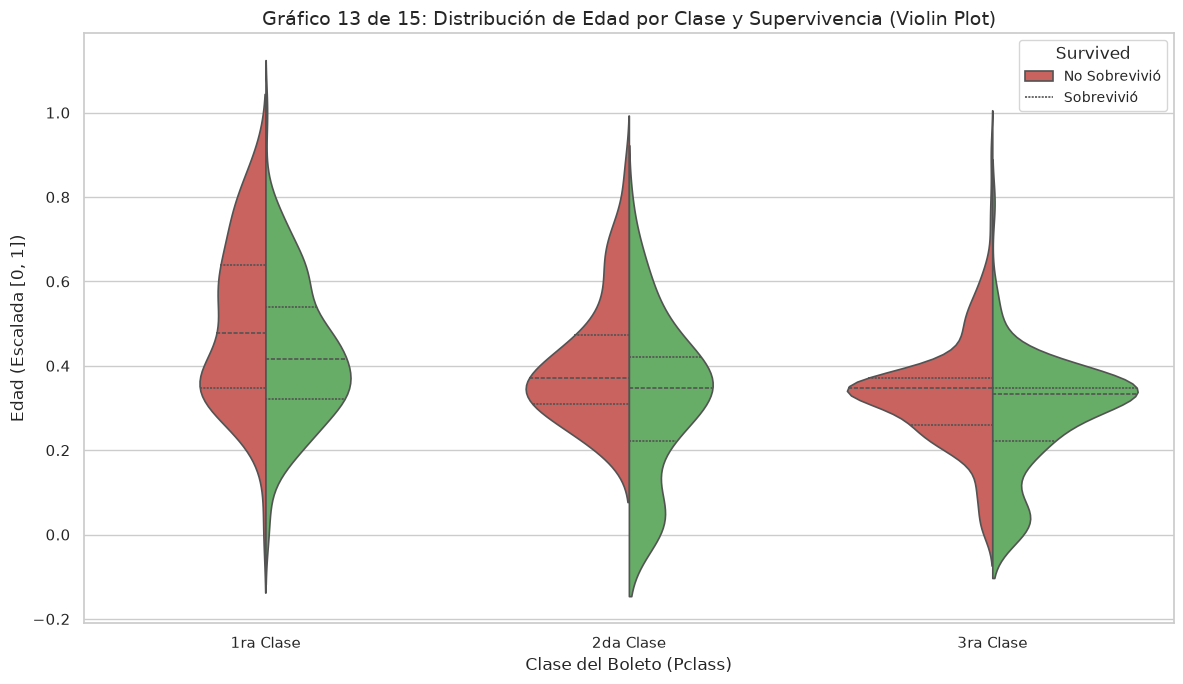

In [17]:
# Gráfico 13 de 15: Distribución de Edad por Clase y Supervivencia (Violin Plot Multivariado)
# El violin plot combina un boxplot con un KDE para revelar la forma completa de la distribución.
# Evaluamos si la distribución etaria de sobrevivientes difiere según la clase del boleto.
fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    data=df_clean,
    x='Pclass',
    y='Age',
    hue='Survived',
    split=True,
    inner='quartile',
    palette={0: '#d9534f', 1: '#5cb85c'},
    ax=ax,
    linewidth=1.2
)

# Corrección de Warning: set_xticks antes de set_xticklabels
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1ra Clase', '2da Clase', '3ra Clase'])

ax.set_title('Gráfico 13 de 15: Distribución de Edad por Clase y Supervivencia (Violin Plot)', fontsize=14)
ax.set_xlabel('Clase del Boleto (Pclass)', fontsize=12)
ax.set_ylabel('Edad (Escalada [0, 1])', fontsize=12)
ax.legend(title='Survived', labels=['No Sobrevivió', 'Sobrevivió'], fontsize=10)

plt.tight_layout()
plt.show()

### Interpretación:

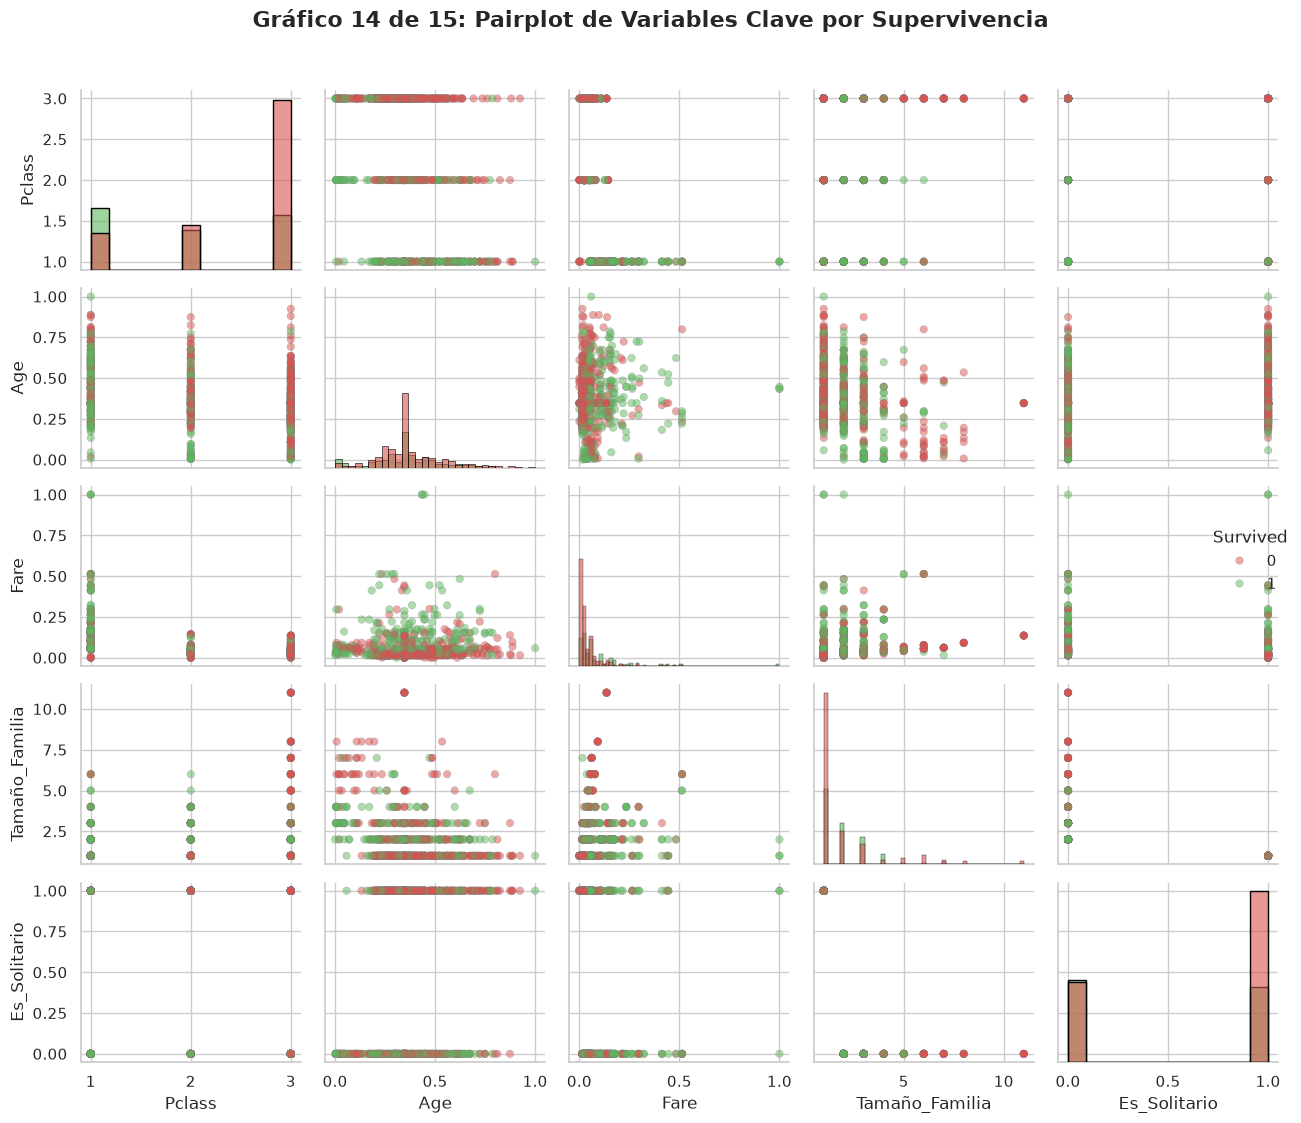

In [18]:
# Gráfico 14 de 15: Pairplot de Variables Clave
# Seleccionamos un subconjunto de variables numéricas relevantes para visualizar
# distribuciones conjuntas (diagonales = histogramas; fuera de diagonal = scatterplots).
# Esto permite detectar rápidamente correlaciones, clusters y outliers entre pares de variables.
variables_pairplot = ['Survived', 'Pclass', 'Age', 'Fare', 'Tamaño_Familia', 'Es_Solitario']

pairplot_fig = sns.pairplot(
    df_clean[variables_pairplot],
    hue='Survived',
    palette={0: '#d9534f', 1: '#5cb85c'},
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 'edgecolor': 'gray', 'linewidth': 0.3, 's': 30},
    diag_kws={'alpha': 0.6, 'edgecolor': 'black'},
    height=2.2,
    aspect=1.1
)

pairplot_fig.figure.suptitle(
    'Gráfico 14 de 15: Pairplot de Variables Clave por Supervivencia',
    fontsize=16, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

### Interpretación:

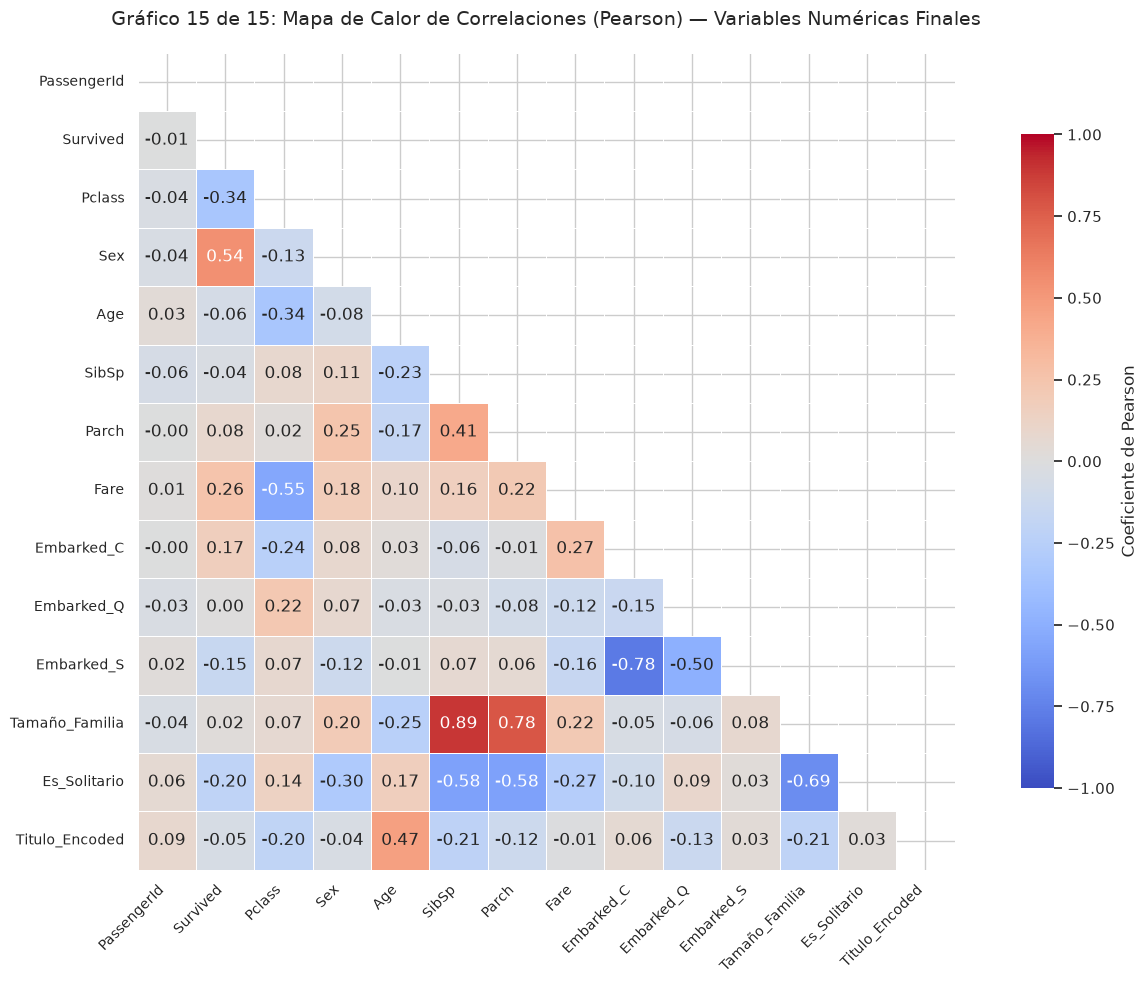

In [19]:
# Gráfico 15 de 15: Mapa de Calor de Correlaciones (Heatmap de Pearson)
# Este gráfico es FUNDAMENTAL para la selección de features antes de entrenar un modelo de ML.
# Permite identificar:
#   - Variables altamente correlacionadas con 'Survived' (candidatas a features del modelo).
#   - Multicolinealidad entre features (que podría degradar modelos lineales).
#   - Relaciones inesperadas que merecen investigación adicional.
fig, ax = plt.subplots(figsize=(14, 10))

# Seleccionamos únicamente las columnas numéricas para la matriz de correlación
columnas_numericas = df_clean.select_dtypes(include=[np.number]).columns
matriz_correlacion = df_clean[columnas_numericas].corr(method='pearson')

# Generamos la máscara triangular superior para evitar redundancia visual
mascara = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# Heatmap con anotaciones numéricas para lectura precisa
sns.heatmap(
    matriz_correlacion,
    mask=mascara,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'},
    ax=ax,
    square=True,
    vmin=-1,
    vmax=1
)

ax.set_title('Gráfico 15 de 15: Mapa de Calor de Correlaciones (Pearson) — Variables Numéricas Finales',
             fontsize=14, pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### Interpretación:

## Conclusión General de Preprocesamiento